# Transformer-based Multi-task Classifier for Lung CT Images

This notebook trains a transformer-based backbone with two heads:
1. **Binary Head:** detects whether a scan is diseased (any of the carcinoma / benign classes) or normal.
2. **Multi-class Head:** if diseased, predicts the disease class among {Benign, Adenocarcinoma, Large cell carcinoma, Squamous Cell Carcinoma}.

Notebook assumptions:
- Dataset folder structure:
  ```
  ./Dataset/
      Benign/
      Normal/
      Adenocarcinoma/
      Large_cell_carcinoma/
      Squamous_Cell_Carcinoma/
  ```
- Python packages required: `torch`, `torchvision`, `timm`, `scikit-learn`, `numpy`, `matplotlib`, `pandas`

Reference / paper used in review (local file):

[ReviewOfImageProcessingCT.pdf](/mnt/data/ReviewOfImageProcessingCT.pdf)

Adjust hyperparameters below as required (batch size, epochs, learning rate).

In [1]:
# --- Imports ---
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('torch:', torch.__version__)
print('timm available')


torch: 2.5.1+cu124
timm available


In [2]:
# --- USER CONFIG ---
DATA_DIR = './Dataset'  # change if needed
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 20
LR = 3e-4
SEED = 42
BACKBONE = 'swin_small_patch4_window7_224'  # or 'vit_base_patch16_224' / 'swin_base_patch4_window7_224'
PRETRAINED = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [3]:
# --- Build file list and labels ---
class_names = [
    'Benign',
    'Normal',
    'Adenocarcinoma',
    'Large_cell_carcinoma',
    'Squamous_Cell_Carcinoma'
]

all_files = []
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        print(f'Warning: class folder not found: {cls_dir}')
        continue
    for p in Path(cls_dir).glob('*'):
        if p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
            all_files.append((str(p), cls))

print('Found examples per class:')
counts = {}
for cls in class_names:
    counts[cls] = sum(1 for f,c in all_files if c==cls)
    print(f'  {cls}:', counts[cls])

if len(all_files) == 0:
    raise RuntimeError('No images found in DATA_DIR. Fix DATA_DIR or dataset layout.')

# Make dataframe
df = pd.DataFrame(all_files, columns=['path','class'])
# Create binary label: disease = 1 if not Normal
df['binary_label'] = (df['class'] != 'Normal').astype(int)
# Create numeric multi-class labels for diseased classes (0..3) but keep -1 for Normal
disease_map = {c:i for i,c in enumerate([c for c in class_names if c!='Normal'])}
def multi_label_from_row(r):
    if r['class'] == 'Normal':
        return -1
    return disease_map[r['class']]
df['multi_label'] = df.apply(multi_label_from_row, axis=1)

df.head()


Found examples per class:
  Benign: 120
  Normal: 631
  Adenocarcinoma: 337
  Large_cell_carcinoma: 187
  Squamous_Cell_Carcinoma: 260


,path,class,binary_label,multi_label
0,Dataset\Benign\Benign cases (1).jpg,Benign,1,0
1,Dataset\Benign\Benign cases (10).jpg,Benign,1,0
2,Dataset\Benign\Benign cases (100).jpg,Benign,1,0
3,Dataset\Benign\Benign cases (101).jpg,Benign,1,0
4,Dataset\Benign\Benign cases (102).jpg,Benign,1,0


In [4]:
# --- Train / Val split ---
train_df, val_df = train_test_split(df, test_size=0.20, stratify=df['class'], random_state=SEED)
print('Train size:', len(train_df), 'Val size:', len(val_df))
train_df['class'].value_counts(), val_df['class'].value_counts()


Train size: 1228 Val size: 307


(class
 Normal                     505
 Adenocarcinoma             269
 Squamous_Cell_Carcinoma    208
 Large_cell_carcinoma       150
 Benign                      96
 Name: count, dtype: int64,
 class
 Normal                     126
 Adenocarcinoma              68
 Squamous_Cell_Carcinoma     52
 Large_cell_carcinoma        37
 Benign                      24
 Name: count, dtype: int64)

In [5]:
# --- Dataset class and transforms ---
train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class LungCTDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transforms:
            img = self.transforms(img)
        binary = torch.tensor(row['binary_label'], dtype=torch.long)
        multi = torch.tensor(row['multi_label'], dtype=torch.long)
        return img, binary, multi

train_ds = LungCTDataset(train_df, transforms=train_transforms)
val_ds = LungCTDataset(val_df, transforms=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('Dataloaders ready — train batches:', len(train_loader), 'val batches:', len(val_loader))


Dataloaders ready — train batches: 77 val batches: 20


In [6]:
# --- Model: Shared transformer backbone + two heads ---
class MultiTaskTransformer(nn.Module):
    def __init__(self, backbone_name='swin_small_patch4_window7_224', pretrained=True, num_classes_multi=4):
        super().__init__()
        # Create backbone via timm
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        feat_dim = self.backbone.num_features
        # Binary head (disease vs normal)
        self.binary_head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
        # Multi-class head (only meaningful if diseased)
        self.multi_head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes_multi)
        )
    def forward(self, x):
        feats = self.backbone(x)
        out_bin = self.binary_head(feats)
        out_multi = self.multi_head(feats)
        return out_bin, out_multi

model = MultiTaskTransformer(BACKBONE, PRETRAINED, num_classes_multi=4).to(device)
print(model)


C:\Users\Tahir\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


MultiTaskTransformer(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384

In [7]:
# --- Losses, optimizer, scheduler ---
criterion_bin = nn.CrossEntropyLoss()
criterion_multi = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


In [8]:
# --- Training & validation loops ---
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_bin_preds = []
    all_bin_targets = []
    for imgs, bin_lbls, multi_lbls in loader:
        imgs = imgs.to(device)
        bin_lbls = bin_lbls.to(device)
        multi_lbls = multi_lbls.to(device)
        optimizer.zero_grad()
        out_bin, out_multi = model(imgs)
        # Binary loss
        loss_bin = criterion_bin(out_bin, bin_lbls)
        # Multi loss: only compute for diseased samples in the batch
        # For Normal multi_lbl == -1; mask them out
        mask = (multi_lbls >= 0)
        if mask.any():
            loss_multi = criterion_multi(out_multi[mask], multi_lbls[mask])
        else:
            loss_multi = torch.tensor(0.0, device=device)
        # Combine losses (weights can be tuned)
        loss = loss_bin + 0.8 * loss_multi
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        # preds for binary
        preds = torch.argmax(out_bin.detach().cpu(), dim=1).numpy()
        all_bin_preds.extend(preds.tolist())
        all_bin_targets.extend(bin_lbls.detach().cpu().numpy().tolist())
    avg_loss = total_loss / (len(loader.dataset))
    acc = accuracy_score(all_bin_targets, all_bin_preds)
    return avg_loss, acc

def validate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_bin_preds = []
    all_bin_targets = []
    all_multi_preds = []
    all_multi_targets = []
    with torch.no_grad():
        for imgs, bin_lbls, multi_lbls in loader:
            imgs = imgs.to(device)
            bin_lbls = bin_lbls.to(device)
            multi_lbls = multi_lbls.to(device)
            out_bin, out_multi = model(imgs)
            loss_bin = criterion_bin(out_bin, bin_lbls)
            mask = (multi_lbls >= 0)
            if mask.any():
                loss_multi = criterion_multi(out_multi[mask], multi_lbls[mask])
            else:
                loss_multi = torch.tensor(0.0, device=device)
            loss = loss_bin + 0.8 * loss_multi
            total_loss += loss.item() * imgs.size(0)
            # binary preds
            preds_bin = torch.argmax(out_bin.detach().cpu(), dim=1).numpy()
            all_bin_preds.extend(preds_bin.tolist())
            all_bin_targets.extend(bin_lbls.detach().cpu().numpy().tolist())
            # multi preds (only consider diseased samples for metrics)
            if mask.any():
                preds_multi = torch.argmax(out_multi[mask].detach().cpu(), dim=1).numpy()
                all_multi_preds.extend(preds_multi.tolist())
                all_multi_targets.extend(multi_lbls[mask].detach().cpu().numpy().tolist())
    avg_loss = total_loss / (len(loader.dataset))
    bin_acc = accuracy_score(all_bin_targets, all_bin_preds)
    multi_acc = None
    if len(all_multi_targets) > 0:
        multi_acc = accuracy_score(all_multi_targets, all_multi_preds)
    return avg_loss, bin_acc, multi_acc, (all_bin_targets, all_bin_preds, all_multi_targets, all_multi_preds)


In [9]:
# --- Run training ---
best_val_acc = 0.0
history = []
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_bin_acc, val_multi_acc, preds = validate(model, val_loader, device)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f}, Train bin acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, Val bin acc: {val_bin_acc:.4f}, Val multi acc: {val_multi_acc}')
    history.append((train_loss, train_acc, val_loss, val_bin_acc, val_multi_acc))
    # scheduler step (monitor binary acc)
    scheduler.step(val_bin_acc)
    # save best
    if val_bin_acc > best_val_acc:
        best_val_acc = val_bin_acc
        torch.save(model.state_dict(), 'best_multitask_transformer.pth')
        print('Saved best model')

print('Training completed. Best val binary acc:', best_val_acc)


Epoch 1/20 | Train loss: 1.1789, Train bin acc: 0.8697 | Val loss: 1.0267, Val bin acc: 0.9088, Val multi acc: 0.4972375690607735
Saved best model
Epoch 2/20 | Train loss: 0.9807, Train bin acc: 0.8933 | Val loss: 0.9506, Val bin acc: 0.9088, Val multi acc: 0.5414364640883977
Epoch 3/20 | Train loss: 0.9363, Train bin acc: 0.8925 | Val loss: 0.8215, Val bin acc: 0.9186, Val multi acc: 0.6243093922651933
Saved best model
Epoch 4/20 | Train loss: 0.9683, Train bin acc: 0.8950 | Val loss: 0.9777, Val bin acc: 0.9088, Val multi acc: 0.5082872928176796
Epoch 5/20 | Train loss: 0.9736, Train bin acc: 0.8958 | Val loss: 0.8283, Val bin acc: 0.9088, Val multi acc: 0.7071823204419889
Epoch 6/20 | Train loss: 0.8163, Train bin acc: 0.8950 | Val loss: 0.8841, Val bin acc: 0.9055, Val multi acc: 0.6353591160220995
Epoch 7/20 | Train loss: 0.7079, Train bin acc: 0.8990 | Val loss: 0.8403, Val bin acc: 0.9088, Val multi acc: 0.6519337016574586
Epoch 8/20 | Train loss: 0.6276, Train bin acc: 0.9088 |

In [10]:
# --- Evaluation & reports on validation set ---
bin_targets, bin_preds, multi_targets, multi_preds = preds
print('Binary classification report (Normal vs Disease):')
print(classification_report(bin_targets, bin_preds, target_names=['Normal','Disease']))
print('\nConfusion matrix (binary):')
print(confusion_matrix(bin_targets, bin_preds))

if len(multi_targets) > 0:
    print('\nMulti-class disease classification report:')
    # Map numeric labels back to disease names
    inv_disease_map = {v:k for k,v in disease_map.items()}
    target_names = [inv_disease_map[i] for i in range(len(inv_disease_map))]
    print(classification_report(multi_targets, multi_preds, target_names=target_names))
    print('\nConfusion matrix (multi-class):')
    print(confusion_matrix(multi_targets, multi_preds))
else:
    print('\nNo diseased samples were present in validation predictions for multi-class evaluation.')


Binary classification report (Normal vs Disease):
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       126
     Disease       0.98      0.96      0.97       181

    accuracy                           0.96       307
   macro avg       0.96      0.96      0.96       307
weighted avg       0.96      0.96      0.96       307


Confusion matrix (binary):
[[122   4]
 [  7 174]]

Multi-class disease classification report:
                         precision    recall  f1-score   support

                 Benign       1.00      1.00      1.00        24
         Adenocarcinoma       0.90      0.97      0.94        68
   Large_cell_carcinoma       0.97      0.95      0.96        37
Squamous_Cell_Carcinoma       0.98      0.90      0.94        52

               accuracy                           0.95       181
              macro avg       0.96      0.96      0.96       181
           weighted avg       0.95      0.95      0.95       181


Conf

C:\Users\Tahir\AppData\Local\Temp\ipykernel_9016\4089644347.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_multitask_transformer.

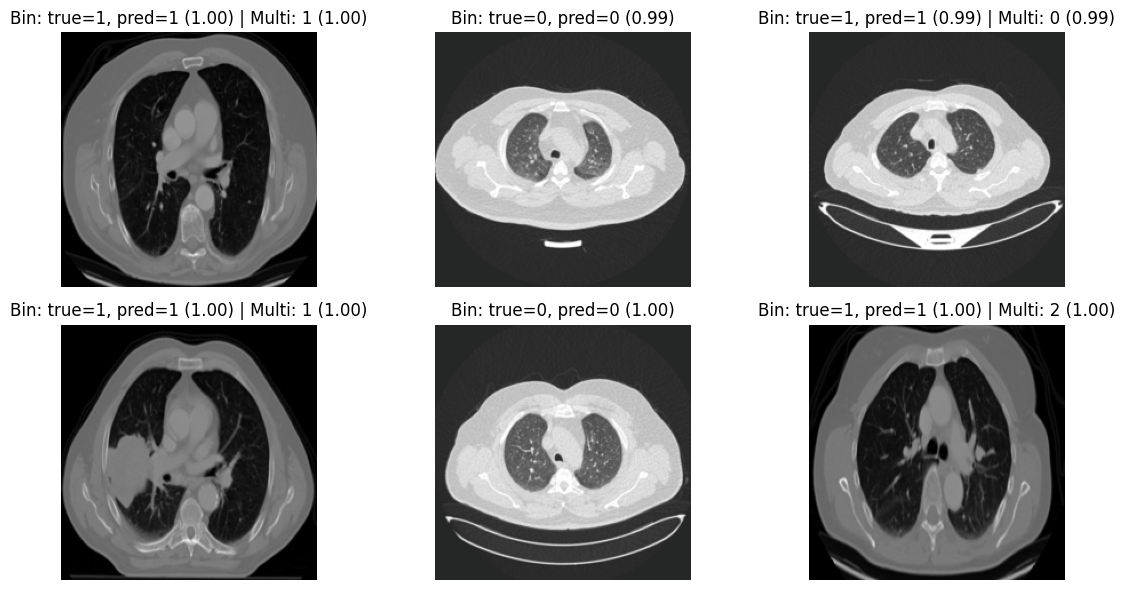

In [11]:
# --- Visualize a few predictions with probability ---
import torch.nn.functional as F

model.load_state_dict(torch.load('best_multitask_transformer.pth', map_location=device))
model.eval()

def show_batch_predictions(loader, n=6):
    imgs, bins, multis = next(iter(loader))
    imgs = imgs.to(device)
    with torch.no_grad():
        out_bin, out_multi = model(imgs)
        probs_bin = F.softmax(out_bin, dim=1).cpu().numpy()
        probs_multi = F.softmax(out_multi, dim=1).cpu().numpy()
    figs = []
    plt.figure(figsize=(12,6))
    for i in range(min(n, imgs.size(0))):
        im = imgs[i].cpu()
        im = im * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        im = np.clip(im.permute(1,2,0).numpy(), 0, 1)
        plt.subplot(2, n//2, i+1)
        plt.imshow(im)
        true_bin = bins[i].item()
        pred_bin = int(np.argmax(probs_bin[i]))
        txt = f'Bin: true={true_bin}, pred={pred_bin} ({probs_bin[i][pred_bin]:.2f})'
        if pred_bin == 1:
            pred_multi = np.argmax(probs_multi[i])
            txt += f' | Multi: {pred_multi} ({probs_multi[i][pred_multi]:.2f})'
        plt.title(txt)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch_predictions(val_loader, n=6)


### Next steps / improvements (suggested)
- Use **self-supervised pretraining** (DINO/SimCLR) on all unlabeled CT slices to improve backbone representations.
- Try ensemble of Swin + hybrid CNN–Transformer for better performance.
- Use class-balancing, focal loss or oversampling for minority classes (e.g., Benign).
- Evaluate on external dataset (other site / scanner) for generalization.
- Add explainability: Grad-CAM / attention rollout for clinical trust.
